In this part, we want to analyse the data we generated. 

# imports

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# file paths

In [8]:
# these are the files you just generated using the napari interface. 
cy3_spots = '../cy3_spots.pkl'
cy5_spots = '../cy5_spots.pkl'
cell_labels = '../segmentation.pkl'

In [9]:
cells = pd.read_pickle(cell_labels)

In [10]:
cells

,cell_label
0,1
1,2
2,3
3,4
4,5
...,...
184,185
185,186
186,187
187,188


# cy 5 channel

In [11]:
cy5_spots_data = pd.read_pickle(cy5_spots)

In [12]:
#inspect data 
cy5_spots_data.head()

,row,column,cell_id,spot_intensities,nuclear_intensity
0,924,870,79,37580,13930
1,1056,977,98,20925,4188
2,679,510,59,27492,4370
3,687,515,59,27018,5516
4,783,2063,74,24849,3371


In [13]:
# plot histograms of spots per cell:

### cy 5 - transcripts per cell 

C:\Users\eniko\AppData\Local\Temp\ipykernel_3356\1733228216.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cy5_counts = (cy5_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()


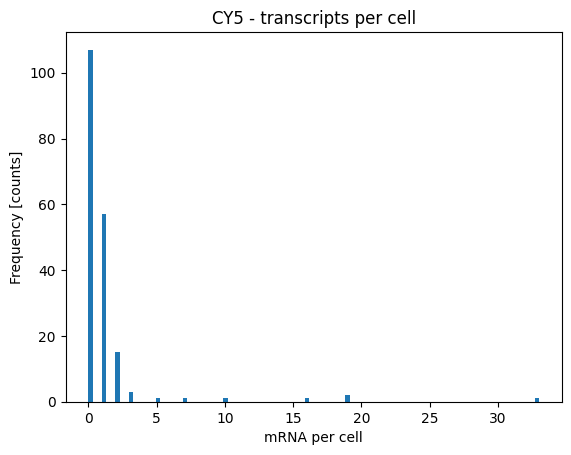

In [14]:
cy5_counts = (cy5_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()
).merge(cells, left_index=True, right_on='cell_label', how='outer').fillna(value=0)

cy5_counts.columns = ['counts','cell_label']

cy5_counts['counts'].plot(kind='hist', bins=100)

plt.xlabel('mRNA per cell')
plt.ylabel('Frequency [counts]')
# adjust bin number to better visualise distribution

plt.title('CY5 - transcripts per cell')
plt.savefig('cy5_transcripts_per_cell.png')

### cy5 - mRNAs per transcription site

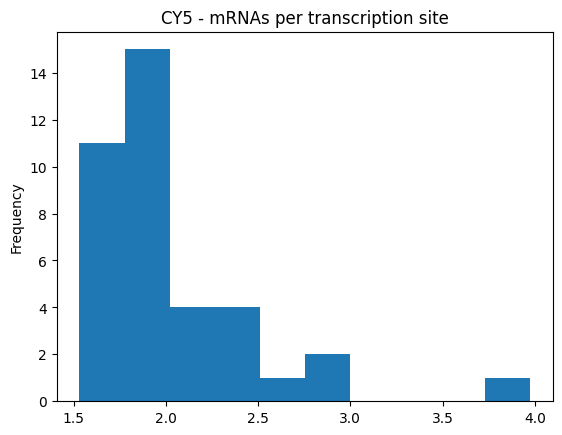

In [15]:
intensities = cy5_spots_data['spot_intensities']
mean_intensity = np.mean(intensities)
transcription_site_threshold = 1.5 * mean_intensity
cy5_spots_data['transcription_site_candidate'] = intensities > transcription_site_threshold

# check the max projection of the DAPI channel for appropriate intensities
# find appropriate values in napari
nuclear_intensity_threshold = 0.8

cy5_spots_data['nuclear_localisation'] = cy5_spots_data['nuclear_intensity'] > nuclear_intensity_threshold
cy5_spots_data['transcription_sites'] = (
    cy5_spots_data['transcription_site_candidate'] & cy5_spots_data['nuclear_localisation'])

(cy5_spots_data[cy5_spots_data['transcription_sites']]['spot_intensities']/mean_intensity).plot(kind='hist')

plt.title('CY5 - mRNAs per transcription site')
plt.savefig('cy5_mRNAs_per_transcription_site.png')

# cy 3 channel

In [16]:
cy3_spots_data = pd.read_pickle(cy3_spots)

In [17]:
#inspect data 
cy3_spots_data.head()

,row,column,cell_id,spot_intensities,nuclear_intensity
0,1017,657,93,14487,12804
1,1629,1194,146,12605,11601
2,438,829,34,10885,2033
3,971,1641,89,11116,3295
4,502,1037,42,11650,2822


### cy 3 - transcripts per cell 

C:\Users\eniko\AppData\Local\Temp\ipykernel_3356\697677154.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cy3_counts = (cy3_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()


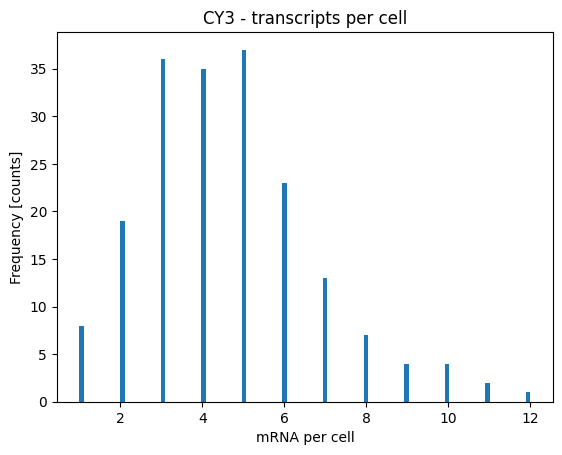

In [18]:
cy3_counts = (cy3_spots_data.groupby('cell_id').apply(lambda x: len(x)).to_frame()
).merge(cells, left_index=True, right_on='cell_label', how='outer').fillna(value=0)

cy3_counts.columns = ['counts','cell_label']

cy3_counts['counts'].plot(kind='hist', bins=100)

plt.xlabel('mRNA per cell')
plt.ylabel('Frequency [counts]')
# adjust bin number to better visualise distribution

plt.title('CY3 - transcripts per cell')
plt.savefig('cy3_transcripts_per_cell.png')

### cy3 - mRNAs per transcription site

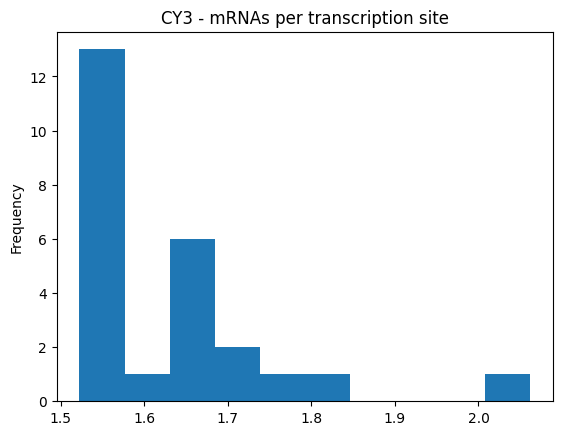

In [19]:
intensities = cy3_spots_data['spot_intensities']
mean_intensity = np.mean(intensities)
transcription_site_threshold = 1.5 * mean_intensity
cy3_spots_data['transcription_site_candidate'] = intensities > transcription_site_threshold

# check the max proejction of the DAPI channel for appropriate intensities
# find appropriate values in napari
nuclear_intensity_threshold = 0.8

cy3_spots_data['nuclear_localisation'] = cy3_spots_data['nuclear_intensity'] > nuclear_intensity_threshold
cy3_spots_data['transcription_sites'] = (
    cy3_spots_data['transcription_site_candidate'] & cy3_spots_data['nuclear_localisation'])

(cy3_spots_data[cy3_spots_data['transcription_sites']]['spot_intensities']/mean_intensity).plot(kind='hist')

plt.title('CY3 - mRNAs per transcription site')
plt.savefig('cy3_mRNAs_per_transcription_site.png')